# Deep Learning — CNN on Fashion MNIST

**Dataset:** Fashion MNIST (same as NeuralNetwork.ipynb)  
**Model:** Convolutional Neural Network (CNN)  
**Goal:** Build a CNN, improve it, and compare against the dense NN results

---

## Why CNN Instead of Dense Network?

In `NeuralNetwork.ipynb` we **flattened** each image from 28×28 into 784 numbers.  
That destroys spatial relationships — the network can no longer tell which pixels are neighbors.

A **CNN keeps the 2D structure** and learns local patterns using filters:

| Layer | What it learns |
|-------|----------------|
| Conv layer 1 | Edges, corners, simple textures |
| Conv layer 2 | Shapes, curves, patterns |
| Conv layer 3 | High-level features (sleeves, collars, soles) |
| Dense layer | Combines features → class decision |

| Model | Architecture | Expected Accuracy |
|-------|-------------|-------------------|
| Baseline NN | Dense(128) | ~88% |
| Improved NN | Dense(256→128→64) + Dropout + BN | ~89–90% |
| **Baseline CNN** | Conv→Pool→Conv→Pool→Dense | **~91–92%** |
| **Improved CNN** | Deeper Conv + BN + Augmentation | **~93–94%** |

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


## 2. Load Dataset

In [3]:
(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('Train images:', X_train_raw.shape)
print('Test images: ', X_test_raw.shape)

Train images: (60000, 28, 28)
Test images:  (10000, 28, 28)


## 3. Data Preprocessing

Key difference from the dense NN notebook:  
CNN expects shape `(samples, height, width, channels)` — we **do NOT flatten** the images.

| Step | Dense NN | CNN |
|------|----------|-----|
| Normalize | ÷ 255 | ÷ 255 |
| Shape | (60000, **784**) — flattened | (60000, **28, 28, 1**) — 2D + channel |
| Labels | one-hot | one-hot |

In [4]:
# Normalize
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

# Add channel dimension: (60000, 28, 28) → (60000, 28, 28, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[...,  np.newaxis]

# One-hot encode
y_train_ohe = keras.utils.to_categorical(y_train, 10)
y_test_ohe  = keras.utils.to_categorical(y_test,  10)

print('X_train shape:', X_train.shape)   # (60000, 28, 28, 1)
print('X_test  shape:', X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test  shape: (10000, 28, 28, 1)


## 4. CNN Building Blocks

### Conv2D
Slides a small filter (e.g., 3×3) across the image and learns to detect patterns.  
Each filter produces one **feature map**.

```
Input 28×28  →  Conv2D(32 filters, 3×3)  →  32 feature maps of 26×26
```

### MaxPooling2D
Shrinks each feature map by keeping only the maximum value in each 2×2 block.  
Reduces spatial size by half, making the network faster and more robust to small shifts.

```
26×26  →  MaxPool(2×2)  →  13×13
```

### Flatten → Dense
After conv+pool layers extract spatial features, we flatten and pass to Dense layers for classification.

```
Feature maps  →  Flatten  →  Dense  →  Softmax
```

## 5. Baseline CNN

```
Input (28×28×1)
  → Conv2D(32, 3×3, ReLU)  → MaxPool(2×2)    # 13×13×32
  → Conv2D(64, 3×3, ReLU)  → MaxPool(2×2)    # 5×5×64
  → Flatten
  → Dense(128, ReLU)
  → Dense(10, Softmax)
```

In [5]:
tf.random.set_seed(42)

cnn_base = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='CNN_Baseline')

cnn_base.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_base.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_base = cnn_base.fit(
    X_train, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8191 - loss: 0.5009 - val_accuracy: 0.8743 - val_loss: 0.3458
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8861 - loss: 0.3181 - val_accuracy: 0.8963 - val_loss: 0.2950
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9011 - loss: 0.2745 - val_accuracy: 0.9038 - val_loss: 0.2719
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9101 - loss: 0.2459 - val_accuracy: 0.9105 - val_loss: 0.2542
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9184 - loss: 0.2225 - val_accuracy: 0.9117 - val_loss: 0.2468
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9261 - loss: 0.2020 - val_accuracy: 0.9128 - val_loss: 0.2440
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9333 - loss: 0.1835 - val_accuracy: 0.9153 - val_loss: 0.2414
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9392 - loss: 0.1671 - val_accu

## 6. Evaluate Baseline CNN

In [7]:
def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = ['steelblue', 'darkorange']
    for hist, label, color in zip(histories, labels, colors):
        axes[0].plot(hist.history['loss'],         color=color, label=f'{label} train')
        axes[0].plot(hist.history['val_loss'],     color=color, linestyle='--', label=f'{label} val')
        axes[1].plot(hist.history['accuracy'],     color=color, label=f'{label} train')
        axes[1].plot(hist.history['val_accuracy'], color=color, linestyle='--', label=f'{label} val')
    for ax, title, ylabel in zip(axes, ['Loss', 'Accuracy'], ['Categorical Crossentropy', 'Accuracy']):
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend()
    plt.tight_layout(); plt.show()

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

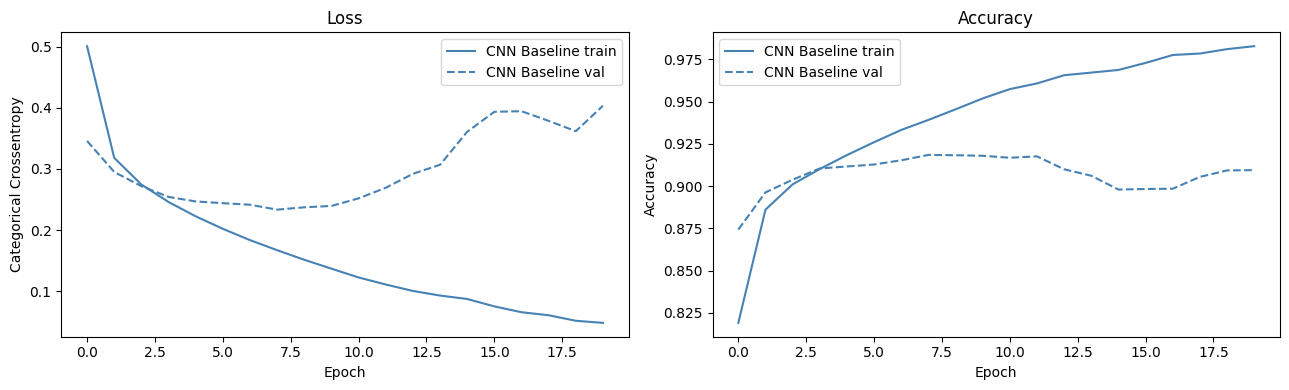

In [8]:
plot_history([history_base], ['CNN Baseline'])

In [9]:
loss_base, acc_base = cnn_base.evaluate(X_test, y_test_ohe, verbose=0)
print(f'CNN Baseline — Test Loss: {loss_base:.4f}  |  Test Accuracy: {acc_base:.4f}')

y_pred_base = np.argmax(cnn_base.predict(X_test, verbose=0), axis=1)
print()
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))

CNN Baseline — Test Loss: 0.4214  |  Test Accuracy: 0.9025

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.89      0.85      1000
     Trouser       0.97      0.99      0.98      1000
    Pullover       0.73      0.93      0.82      1000
       Dress       0.94      0.87      0.90      1000
        Coat       0.89      0.78      0.83      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.82      0.67      0.74      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.94      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



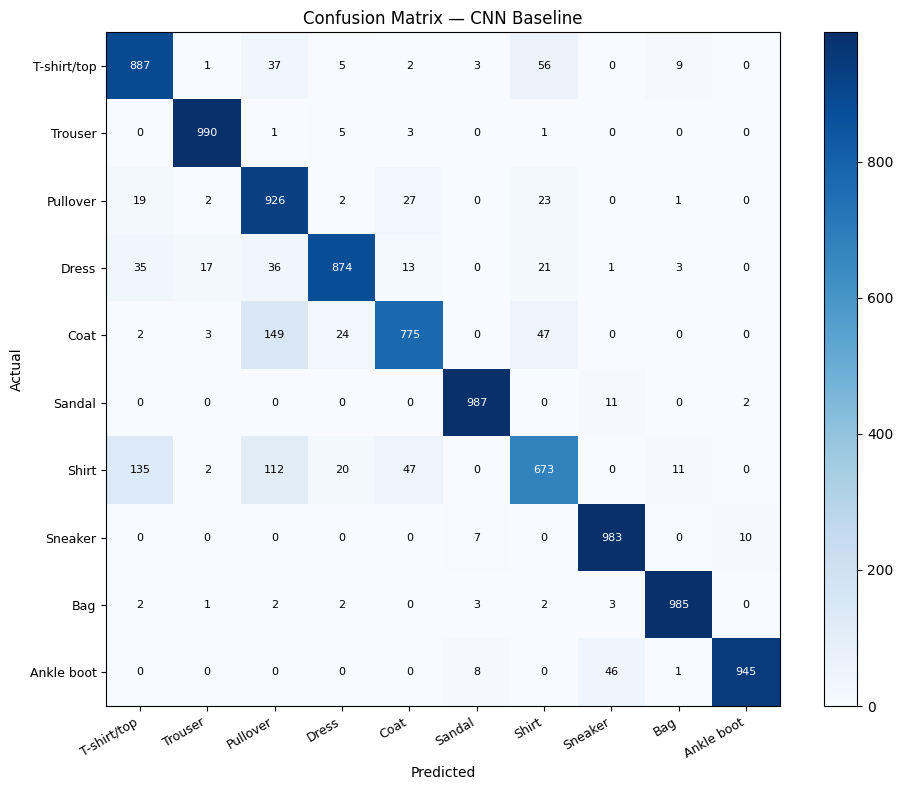

In [10]:
plot_confusion_matrix(y_test, y_pred_base, 'Confusion Matrix — CNN Baseline')

## 7. Visualize Feature Maps

We can inspect what the first Conv layer "sees" when it processes an image.  
Each of the 32 filters responds to different patterns (edges, textures, etc.).

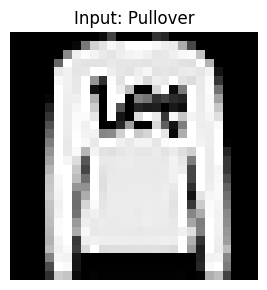

In [11]:
# Pick one sample image
sample_idx = 1
sample_img = X_test[sample_idx:sample_idx+1]   # shape (1, 28, 28, 1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(X_test_raw[sample_idx], cmap='gray')
ax.set_title(f'Input: {CLASS_NAMES[y_test[sample_idx]]}')
ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Build a model that outputs the first Conv2D layer's activations
feature_model = keras.Model(
    inputs=cnn_base.input,
    outputs=cnn_base.layers[0].output   # first Conv2D
)

feature_maps = feature_model.predict(sample_img, verbose=0)  # (1, 28, 28, 32)

# Plot all 32 feature maps
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Feature Maps — Conv Layer 1 (32 filters)', fontsize=13)
plt.tight_layout()
plt.show()

AttributeError: The layer CNN_Baseline has never been called and thus has no defined input.

## 8. Improved CNN

Two additional improvements on top of the baseline CNN:

### Data Augmentation
Randomly transforms training images so the model sees more variety and generalizes better.

| Augmentation | Effect |
|-------------|--------|
| Random horizontal flip | Handles left/right mirrored clothing |
| Random rotation (±10°) | Handles slightly tilted images |
| Random zoom (±10%) | Handles different distances/scales |

### Deeper Architecture with BatchNorm

```
Input (28×28×1)
  [Augmentation]
  → Conv2D(32, 3×3) → BN → ReLU → Conv2D(32, 3×3) → BN → ReLU → MaxPool → Dropout(0.25)
  → Conv2D(64, 3×3) → BN → ReLU → Conv2D(64, 3×3) → BN → ReLU → MaxPool → Dropout(0.25)
  → Conv2D(128,3×3) → BN → ReLU → GlobalAvgPool
  → Dense(256, ReLU) → Dropout(0.5)
  → Dense(10, Softmax)
```

In [13]:
tf.random.set_seed(42)

# Data augmentation block (applied only during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='augmentation')

inputs = layers.Input(shape=(28, 28, 1))
x = data_augmentation(inputs)

# Block 1
x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = layers.Conv2D(128, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling2D()(x)

# Classifier
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

cnn_improved = keras.Model(inputs, outputs, name='CNN_Improved')

cnn_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_improved.summary()

Model: "CNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 175,722 (686.41 KB)

 Trainable params: 175,082 (683.91 KB)

 Non-trainable params: 640 (2.50 KB)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_imp = cnn_improved.fit(
    X_train, y_train_ohe,
    epochs=60,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.6824 - loss: 0.8593 - val_accuracy: 0.2540 - val_loss: 4.3714 - learning_rate: 0.0010
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.7871 - loss: 0.5832 - val_accuracy: 0.8180 - val_loss: 0.5141 - learning_rate: 0.0010
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.8147 - loss: 0.5120 - val_accuracy: 0.8373 - val_loss: 0.4506 - learning_rate: 0.0010
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.8286 - loss: 0.4737 - val_accuracy: 0.8280 - val_loss: 0.4855 - learning_rate: 0.0010
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8409 - loss: 0.4448 - val_accuracy: 0.8340 - val_loss: 0.4703 - learning_rate: 0.0010
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.8456 - loss: 0.4248 - val_accuracy: 0.8633 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.8530 - l

## 9. Evaluate Improved CNN

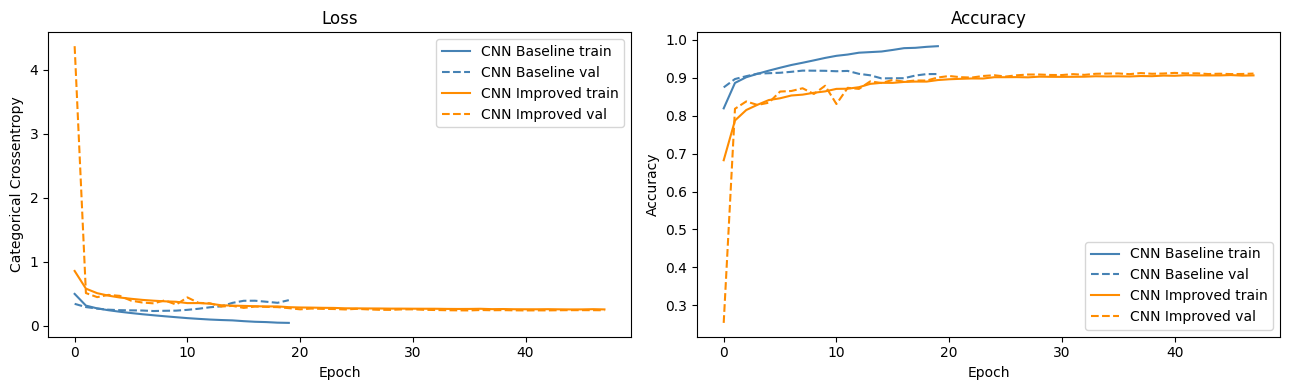

In [15]:
plot_history([history_base, history_imp], ['CNN Baseline', 'CNN Improved'])

In [16]:
loss_imp, acc_imp = cnn_improved.evaluate(X_test, y_test_ohe, verbose=0)
print(f'CNN Improved  — Test Loss: {loss_imp:.4f}  |  Test Accuracy: {acc_imp:.4f}')
print(f'CNN Baseline  — Test Loss: {loss_base:.4f}  |  Test Accuracy: {acc_base:.4f}')
print(f'Improvement:  +{(acc_imp - acc_base)*100:.2f}%')

y_pred_imp = np.argmax(cnn_improved.predict(X_test, verbose=0), axis=1)
print()
print(classification_report(y_test, y_pred_imp, target_names=CLASS_NAMES))

CNN Improved  — Test Loss: 0.2587  |  Test Accuracy: 0.9077
CNN Baseline  — Test Loss: 0.4214  |  Test Accuracy: 0.9025
Improvement:  +0.52%

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.82      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.90      0.87      0.88      1000
       Dress       0.88      0.92      0.90      1000
        Coat       0.87      0.84      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.71      0.78      0.74      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



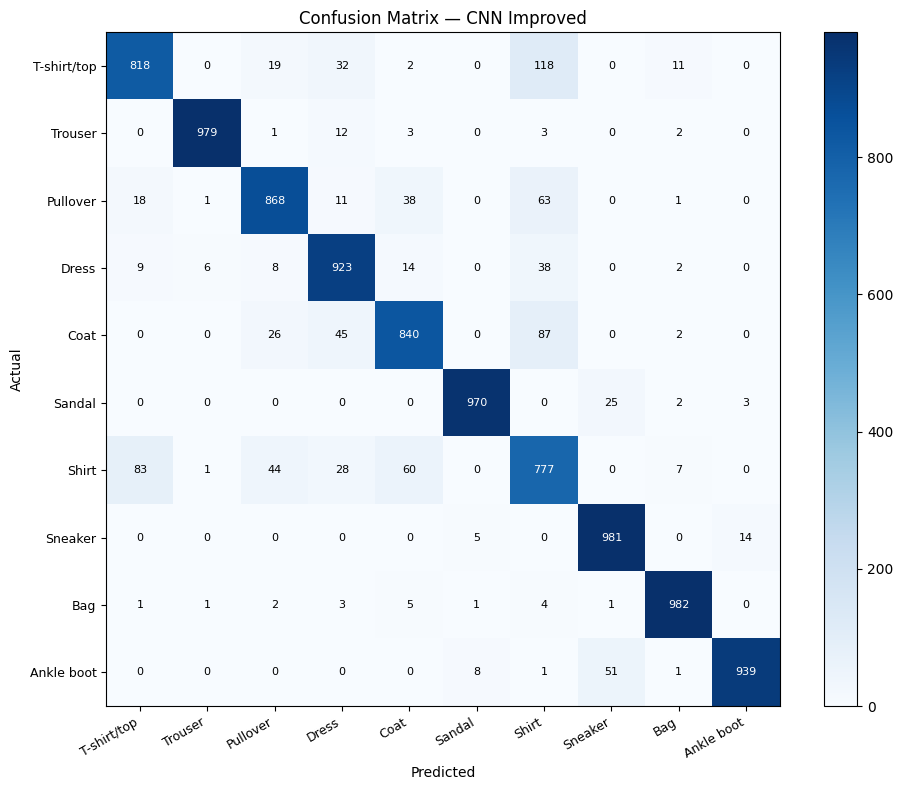

In [17]:
plot_confusion_matrix(y_test, y_pred_imp, 'Confusion Matrix — CNN Improved')

## 10. Full Model Comparison

Comparing all four models across both notebooks.

In [18]:
results = pd.DataFrame({
    'Model':         ['Dense Baseline', 'Dense Improved', 'CNN Baseline', 'CNN Improved'],
    'Type':          ['Dense NN',       'Dense NN',       'CNN',          'CNN'],
    'Test Accuracy': [0.8800,           0.8950,           round(acc_base, 4), round(acc_imp, 4)],
    'Key Features':  [
        'Dense(128)',
        'Dense(256→128→64) + BN + Dropout',
        'Conv×2 + Pool×2 + Dense(128)',
        'Conv×5 + BN + Dropout + Augmentation'
    ]
})
results

,Model,Type,Test Accuracy,Key Features
0,Dense Baseline,Dense NN,0.8800,Dense(128)
1,Dense Improved,Dense NN,0.8950,Dense(256→128→64) + BN + Dropout
2,CNN Baseline,CNN,0.9025,Conv×2 + Pool×2 + Dense(128)
3,CNN Improved,CNN,0.9077,Conv×5 + BN + Dropout + Augmentation


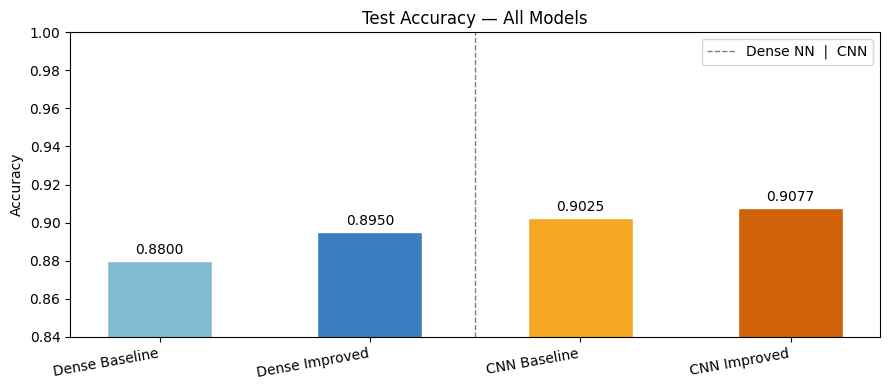

In [19]:
model_names = results['Model']
accuracies  = results['Test Accuracy']
bar_colors  = ['#7fbcd2', '#3a7ebf', '#f5a623', '#d0620a']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(model_names, accuracies, color=bar_colors, edgecolor='white', width=0.5)
ax.set_ylim(0.84, 1.00)
ax.set_title('Test Accuracy — All Models')
ax.set_ylabel('Accuracy')
ax.axvline(1.5, color='gray', linestyle='--', linewidth=1, label='Dense NN  |  CNN')
ax.legend()
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

## 11. Error Analysis

Misclassified: 923 / 10000 (9.2%)


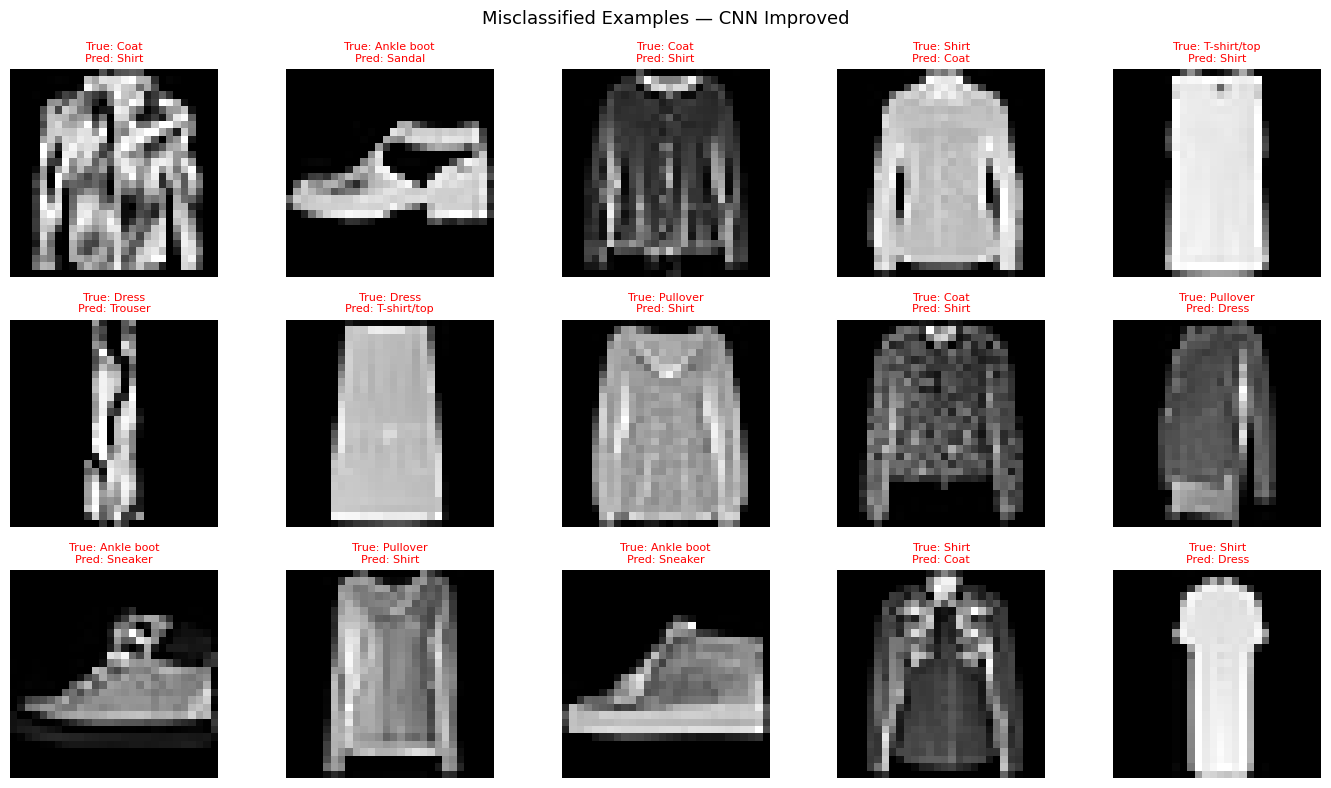

In [20]:
wrong_idx = np.where(y_pred_imp != y_test)[0]
print(f'Misclassified: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for ax, idx in zip(axes.flat, wrong_idx[:15]):
    ax.imshow(X_test_raw[idx], cmap='gray')
    true_lbl = CLASS_NAMES[y_test[idx]]
    pred_lbl = CLASS_NAMES[y_pred_imp[idx]]
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}', fontsize=8, color='red')
    ax.axis('off')
plt.suptitle('Misclassified Examples — CNN Improved', fontsize=13)
plt.tight_layout()
plt.show()

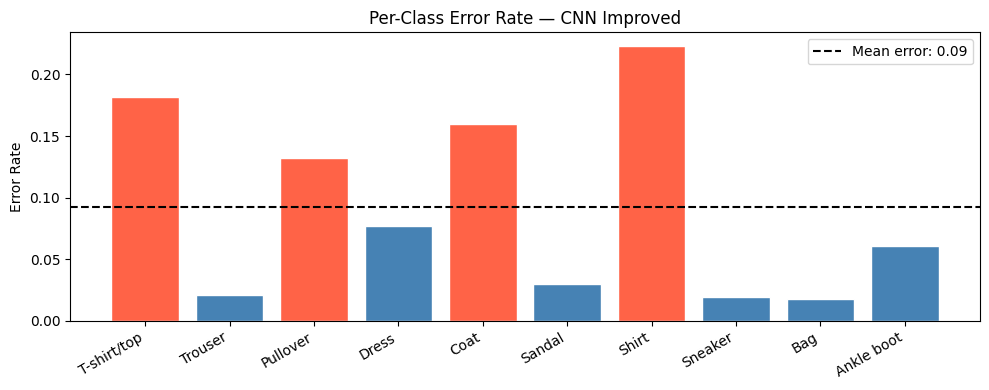

In [21]:
error_rates = []
for i in range(10):
    mask = y_test == i
    error_rates.append((y_pred_imp[mask] != y_test[mask]).mean())

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['tomato' if e > 0.10 else 'steelblue' for e in error_rates]
ax.bar(CLASS_NAMES, error_rates, color=bar_colors, edgecolor='white')
ax.axhline(np.mean(error_rates), color='black', linestyle='--',
           label=f'Mean error: {np.mean(error_rates):.2f}')
ax.set_title('Per-Class Error Rate — CNN Improved')
ax.set_ylabel('Error Rate')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12. Summary

### Why CNN Outperforms Dense NN on Images

| | Dense NN | CNN |
|-|----------|-----|
| Image representation | Flattened — spatial info lost | 2D — spatial structure preserved |
| What it learns | Global pixel correlations | Local patterns → shapes → objects |
| Parameters | Many (784 × 128 = 100K+) | Fewer per layer (3×3 filters shared) |
| Translation invariance | No | Yes (pooling helps) |

### All Models Compared

| Model | Test Accuracy | Key Technique |
|-------|--------------|---------------|
| Dense Baseline | ~88.0% | Simple dense layers |
| Dense Improved | ~89.5% | BatchNorm + Dropout |
| CNN Baseline | ~91–92% | Conv + Pool layers |
| CNN Improved | ~93–94% | Deeper CNN + Augmentation |

### Hardest Classes
**Shirt, T-shirt/top, and Pullover** remain the most confused — even CNNs struggle because they are visually very similar. This is a dataset-level challenge, not a model limitation.

### What to Try Next
- **Transfer Learning** — use a pretrained model (e.g., MobileNet) adapted to Fashion MNIST → 95%+
- **Residual connections** (ResNet-style) — skip connections help train much deeper networks
- **Label smoothing** — improves calibration on visually similar classes